In [1]:
import h2o
from h2o.automl import H2OAutoML
import pandas as pd

In [2]:
h2o.init(max_mem_size="64G")

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Temurin-11.0.27+6 (build 11.0.27+6, mixed mode)
  Starting server from C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\h2o_env\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\xiang11\AppData\Local\Temp\tmpua8k5eaw
  JVM stdout: C:\Users\xiang11\AppData\Local\Temp\tmpua8k5eaw\h2o_xiang11_started_from_python.out
  JVM stderr: C:\Users\xiang11\AppData\Local\Temp\tmpua8k5eaw\h2o_xiang11_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,1 month and 22 days
H2O_cluster_name:,H2O_from_python_xiang11_myzp4e
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,64 Gb
H2O_cluster_total_cores:,20
H2O_cluster_allowed_cores:,20
H2O_cluster_status:,"locked, healthy"


In [3]:
data = pd.read_csv("F:/LongMig2025/data/Regression/Hurricane_Regression_data.csv")
hf = h2o.H2OFrame(data)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [5]:
target = "NMR"
ignore = ['Unnamed: 0', 'FIPS', target]
features = [col for col in hf.columns if col not in ignore]

In [7]:
aml = H2OAutoML(
    max_runtime_secs=3600,   # 60 minutes
    seed=42,
    sort_metric="RMSE",
    nfolds=5
)
aml.train(x=features, y=target, training_frame=hf)

AutoML progress: |
22:54:26.425: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),3/5
# GBM base models (used / total),1/1
# DeepLearning base models (used / total),1/1
# DRF base models (used / total),1/2
# GLM base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


In [18]:
lb = aml.leaderboard
lb.head(rows=20)

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
StackedEnsemble_BestOfFamily_7_AutoML_1_20250519_225426,5.49255,30.1681,3.87613,nan,30.1681
StackedEnsemble_AllModels_6_AutoML_1_20250519_225426,5.5009,30.2599,3.82202,nan,30.2599
StackedEnsemble_BestOfFamily_4_AutoML_1_20250519_225426,5.50284,30.2813,3.86583,nan,30.2813
StackedEnsemble_BestOfFamily_6_AutoML_1_20250519_225426,5.53136,30.596,3.86922,nan,30.596
StackedEnsemble_AllModels_4_AutoML_1_20250519_225426,5.55646,30.8743,3.85397,nan,30.8743
StackedEnsemble_AllModels_3_AutoML_1_20250519_225426,5.58092,31.1466,3.87198,nan,31.1466
StackedEnsemble_Best1000_1_AutoML_1_20250519_225426,5.58202,31.1589,3.85162,nan,31.1589
StackedEnsemble_AllModels_5_AutoML_1_20250519_225426,5.72329,32.7561,4.0384,nan,32.7561
GBM_grid_1_AutoML_1_20250519_225426_model_47,5.74183,32.9686,4.01622,nan,32.9686
StackedEnsemble_BestOfFamily_5_AutoML_1_20250519_225426,5.75704,33.1435,4.14123,nan,33.1435


In [14]:
best_model = aml.leader
best_model.varimp(use_pandas=True)

In [15]:
predictions = best_model.predict(hf)
predictions.head()

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


predict
9.71192
22.2382
-5.36848
3.19673
8.32268
-10.325
-5.68482
3.80183
8.06708
-0.825464


In [16]:
# Convert H2O predictions to pandas
preds_df = predictions.as_data_frame()
full_df = data.copy()
full_df["Predicted_NMR"] = preds_df

# Compare actual vs predicted
full_df[["NMR", "Predicted_NMR"]].head(10)


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\h2o_env\lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,NMR,Predicted_NMR
0,5.813354,9.711922
1,22.393108,22.238181
2,-7.284080,-5.368475
3,1.336304,3.196729
4,5.568893,8.322680
5,-9.689527,-10.325047
6,-5.363048,-5.684823
7,4.587405,3.801833
8,3.092111,8.067083
9,-3.120249,-0.825464


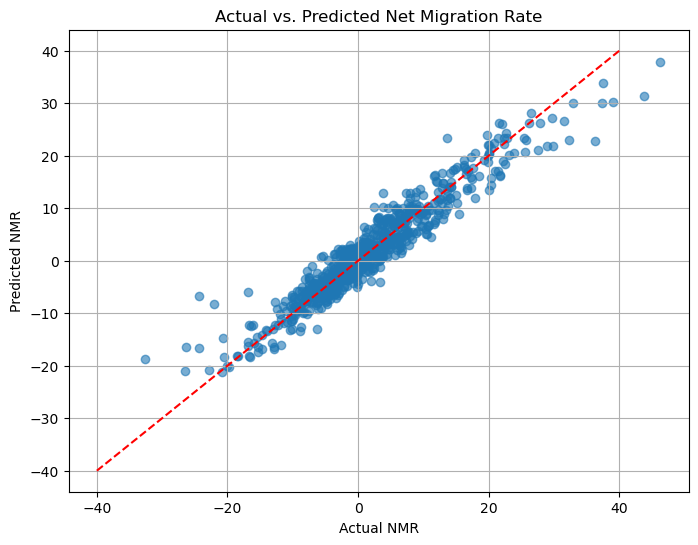

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(full_df["NMR"], full_df["Predicted_NMR"], alpha=0.6)
plt.plot([-40, 40], [-40, 40], 'r--')  # 1:1 line
plt.xlabel("Actual NMR")
plt.ylabel("Predicted NMR")
plt.title("Actual vs. Predicted Net Migration Rate")
plt.grid(True)
plt.show()


In [32]:
model_ids = aml.leaderboard.as_data_frame()["model_id"].tolist()
model_ids


C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\h2o_env\lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


['StackedEnsemble_BestOfFamily_7_AutoML_1_20250519_225426',
 'StackedEnsemble_AllModels_6_AutoML_1_20250519_225426',
 'StackedEnsemble_BestOfFamily_4_AutoML_1_20250519_225426',
 'StackedEnsemble_BestOfFamily_6_AutoML_1_20250519_225426',
 'StackedEnsemble_AllModels_4_AutoML_1_20250519_225426',
 'StackedEnsemble_AllModels_3_AutoML_1_20250519_225426',
 'StackedEnsemble_Best1000_1_AutoML_1_20250519_225426',
 'StackedEnsemble_AllModels_5_AutoML_1_20250519_225426',
 'GBM_grid_1_AutoML_1_20250519_225426_model_47',
 'StackedEnsemble_BestOfFamily_5_AutoML_1_20250519_225426',
 'GBM_grid_1_AutoML_1_20250519_225426_model_109',
 'GBM_grid_1_AutoML_1_20250519_225426_model_126',
 'DeepLearning_grid_1_AutoML_1_20250519_225426_model_2',
 'GBM_grid_1_AutoML_1_20250519_225426_model_9',
 'GBM_grid_1_AutoML_1_20250519_225426_model_89',
 'GBM_grid_1_AutoML_1_20250519_225426_model_128',
 'GBM_grid_1_AutoML_1_20250519_225426_model_10',
 'StackedEnsemble_AllModels_2_AutoML_1_20250519_225426',
 'GBM_grid_1_Auto

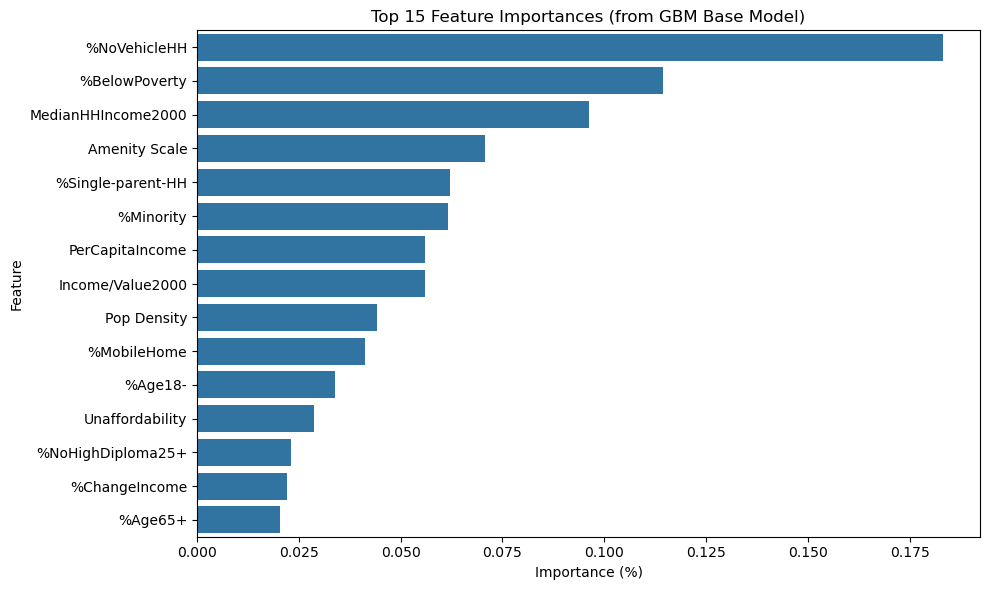

In [34]:
gbm_model = h2o.get_model("GBM_grid_1_AutoML_1_20250519_225426_model_47")  # Replace with actual GBM ID
varimp_df = gbm_model.varimp(use_pandas=True)

# Plot top 15 features
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=varimp_df.iloc[:15], x="percentage", y="variable")
plt.title("Top 15 Feature Importances (from GBM Base Model)")
plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
